In [ ]:
pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import zipfile
import os
from collections import Counter
from IPython.display import display, Javascript
from google.colab.output import eval_js
import numpy as np
import base64

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
uploaded = files.upload()

Saving Electronic Component Detection.v1-electronic_component_detection_roboflow3_fast.yolov8.zip to Electronic Component Detection.v1-electronic_component_detection_roboflow3_fast.yolov8.zip


In [ ]:
zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted!")

Dataset extracted!


In [ ]:
!ls /content/dataset

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 757.6±223.5 MB/s, size: 19.7 KB)
val: Scanning /content/dataset/valid/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 3.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.4it/s 0.4s
                   all         15         41      0.858      0.755      0.845      0.712
             capacitor          5         11      0.819      0.636      0.849      0.742
              resistor         10         30      0.897      0.873      0.841      0.683
Speed: 1.3ms preprocess, 5.2ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.u

In [ ]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Saving Screenshot 2026-05-04 161737.png to Screenshot 2026-05-04 161737.png



image 1/1 /content/Screenshot 2026-05-04 161737.png: 640x512 34 capacitors, 37 resistors, 6.5ms
Speed: 2.3ms preprocess, 6.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 512)

Detected Components:
capacitor : 34
resistor : 37


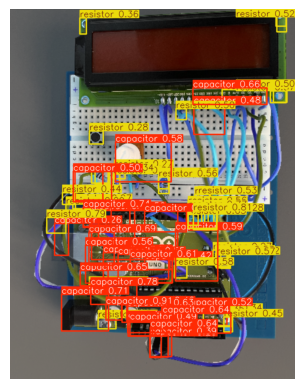

In [ ]:
#Detect Components + Count
model = YOLO("/content/runs/detect/train/weights/best.pt")

results = model(image_path)

counts = Counter()

for r in results:
    for box in r.boxes:
        cls = int(box.cls)
        label = model.names[cls]
        counts[label] += 1

for r in results:
    im = r.plot()
    plt.imshow(im)
    plt.axis("off")

print("\nDetected Components:")

for comp, count in counts.items():
    print(comp, ":", count)

In [ ]:
#Webcam Capture
def take_photo(filename='photo.jpg', quality=0.8):

  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
  ''')

  display(js)
  data = eval_js('takePhoto({})'.format(quality))

  binary = base64.b64decode(data.split(',')[1])

  with open(filename, 'wb') as f:
    f.write(binary)

  return filename

In [ ]:
image_path = take_photo()
print("Saved to", image_path)

<IPython.core.display.Javascript object>

Saved to photo.jpg


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

model.export(format="tflite", imgsz=640)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 271ms
Prepared 4 packages in 6.72s
Installed 4 packages in 378ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 8.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimmi

'/content/runs/detect/train/weights/best_saved_model/best_float32.tflite'


image 1/1 /content/photo.jpg: 480x640 2 capacitors, 42.4ms
Speed: 2.4ms preprocess, 42.4ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

Detected Components:
capacitor : 2


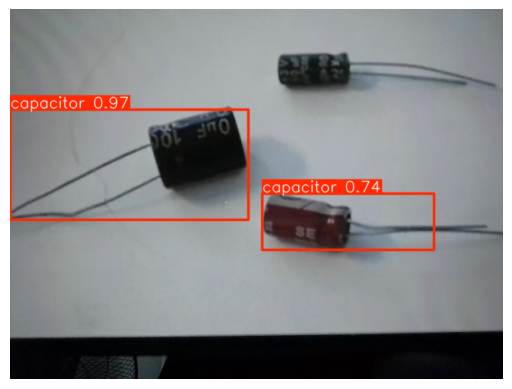

In [ ]:
results = model(image_path)

counts = Counter()

for r in results:
    for box in r.boxes:
        cls = int(box.cls)
        label = model.names[cls]
        counts[label] += 1

for r in results:
    im = r.plot()
    plt.imshow(im)
    plt.axis("off")

print("\nDetected Components:")

for comp, count in counts.items():
    print(comp, ":", count)